In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

Construct binomial distribution data for optimization of a logistic curve

In [3]:
x1 = np.repeat([i+1 for i in range(50)], repeats=1000/50)
x0 = np.ones([1000,])
X = np.column_stack((x0,x1))
B = np.array([-12, 0.5])
def probs(v):
    return 1/(1 + np.exp(-v))
# add noise
np.random.seed(42)
noise = np.random.uniform(-5,5, 1000)
fun_y = X @ B
y = np.round(probs(fun_y + noise), decimals=0)

<function matplotlib.pyplot.show(close=None, block=None)>

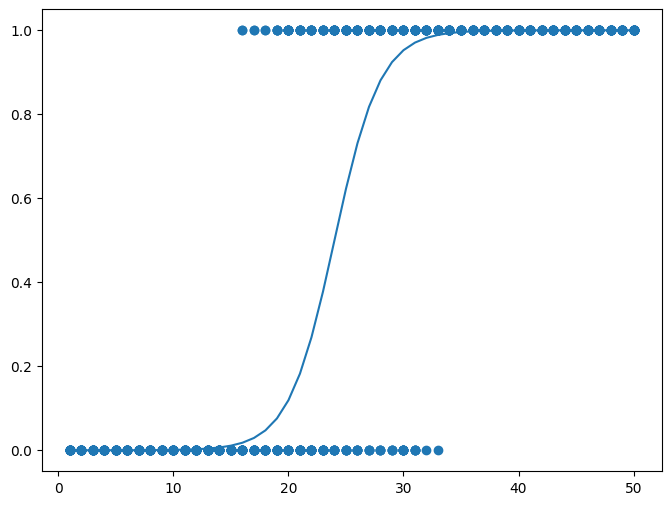

In [4]:
plt.figure(figsize=(8,6))
plt.plot(x1, probs(X @ B))
plt.scatter(x1, y)
plt.show

Derived Negative Log-Likelihood with first and second derivative with respect to all parameters in order to calculate gradients and Hessian.

In [5]:
def NLL(y, p):
    LL = np.sum(y*np.log(p)+(1-y)*np.log(1-p))
    NLL = -LL
    return NLL
def gradient(x, t0, t1, y):
    prob_eq = 1/(1 + np.exp(-(t1*x+t0)))
    t1_grad = np.sum(x*(prob_eq-y))
    t0_grad = np.sum(prob_eq-y)
    return np.array([t0_grad, t1_grad])
def Hessian(x, t0, t1):
    prob_eq = 1/(1 + np.exp(-(t1*x+t0)))
    H = np.zeros((2,2))
    H[0,0] = np.sum(prob_eq*(1-prob_eq))
    H[0,1] = np.sum(x*prob_eq*(1-prob_eq))
    H[1,0] = np.sum(x*prob_eq*(1-prob_eq))
    H[1,1] = np.sum((x**2)*prob_eq*(1-prob_eq))
    return H

Using the Newton Method to optimize coefficients for the logistic regression

In [6]:
T = np.array([0,0])
nll = NLL(y, probs(X @ T))
obj = []
parms = []
alpha = 1
lamb = 1e-10
iter = 1000
for i in range(iter):
    obj.append(nll)
    nll0=nll
    parms.append(T)
    Grads = gradient(X[:,1], T[0], T[1], y)
    H = Hessian(X[:,1], T[0], T[1])
    Omega = -np.linalg.solve(H+lamb*np.eye(len(T)), Grads)
    T = T + alpha*Omega
    nll = NLL(y, probs(X @ T))
    print(f"NLL: {nll} with Max(Omega): {np.max(np.abs(Omega))} in iteration {i}")
    print(f"Theta0: {T[0]} and Theta1: {T[1]}")
    if np.max(np.abs(Omega)) < 1e-4:
        break
    while np.round(nll, decimals=2) > np.round(nll0, decimals=2):
        print(f"old nll: {nll0} versus new nll: {nll} in iteration {i}")
        alpha *= 0.5
        T = T + alpha*Omega
        nll = NLL(y, probs(X @ T))
    alpha = alpha**0.5
    plt.figure(figsize=(8,6))
    plt.plot(X[:,1], probs(X @ T))
    plt.scatter(X[:,1], y, alpha=0.5)
    plt.xlabel("Predictor")
    plt.ylabel("Response")
    plt.show()
    clear_output(wait=True)
    time.sleep(0.5)

NLL: 208.53485465799682 with Max(Omega): 3.0420701798287786e-09 in iteration 7
Theta0: -7.4104130472117316 and Theta1: 0.31468838478168465


In [ ]:
W = np.diag(probs(X @ T)*(1-probs(X @ T))) # variance on the diagonal 
T_var = np.linalg.inv(X.T @ W @ X)
T_stderr = np.sqrt(np.diag(T_var))
print(f"Mean Theta: {T} and StdErr: {T_stderr}")